In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc
import scipy
from itertools import combinations
import pycwt
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import mixture
import statistics

from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score

from itertools import combinations
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

datadir = "/jukebox/hasson/snastase/social-ctf/results"
lstmsNew = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

In [3]:
def mutual_info_binned(x, y, bins=None):
    if not bins:
        bins = int(np.floor(np.sqrt(4501 / 5)))
    c_xy = np.histogram2d(x, y, bins)[0]
    mi = mutual_info_score(None, None, contingency=c_xy)
    return mi

In [40]:
#lstmsNew1 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 
#lstmsNew2 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 
                  
pc=0
coopIds, compIds = [0,5],[1,2,3,4]

data = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
f, Cxy = scipy.signal.coherence(data[0],data[1], fs=15, detrend=False)
xCoh = Cxy[np.newaxis,:]
y = np.array([True])
for map in range(25):
    for repeat in range(31):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]#[0][:,np.newaxis]
        for count,pair in zip(range(6),combinations(np.arange(4),2)):
            if map!=0 or repeat!=0 or count!=0:
                f, Cxy = scipy.signal.coherence(data[pair[0]],data[pair[1]], fs=15, detrend=False)
                xCoh = np.concatenate((xCoh, Cxy[np.newaxis,:]), axis=0)
                y = np.concatenate((y, [count in coopIds]))

In [41]:
trainCoh = xCoh[len(xCoh)//4:]
testCoh = xCoh[:len(xCoh)//4]
trainY = y[len(y)//4:]
testY = y[:len(y)//4]

print(xCoh.shape)
print(y.shape)

(4650, 129)
(4650,)


In [24]:
cohModel = sklearn.linear_model.LogisticRegression().fit(trainCoh, trainY)
#r_sq = model.score(testCoh, testY)
#print(f'r sq: {r_sq}')

predY = cohModel.predict(testCoh)
cm = confusion_matrix(testY, predY)
print ("Confusion Matrix: \n", cm)
print ("Accuracy:", accuracy_score(testY, predY))

Confusion Matrix: 
 [[735  40]
 [339  48]]
Accuracy: 0.6738382099827883


(array([1.133e+03, 2.270e+02, 1.010e+02, 4.800e+01, 2.600e+01, 1.000e+01,
        4.000e+00, 0.000e+00, 1.000e+00, 0.000e+00]),
 array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ]),
 <BarContainer object of 10 artists>)

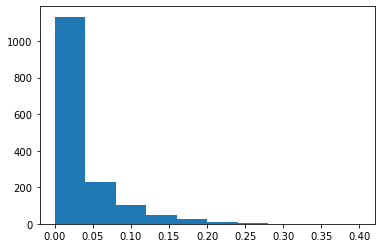

In [45]:
plt.hist(xCoh[y,0], range=(0,0.4))

(array([1594.,  586.,  396.,  237.,  145.,   77.,   37.,   18.,    8.,
           2.]),
 array([1.93052079e-11, 4.52136707e-02, 9.04273415e-02, 1.35641012e-01,
        1.80854683e-01, 2.26068354e-01, 2.71282024e-01, 3.16495695e-01,
        3.61709366e-01, 4.06923036e-01, 4.52136707e-01]),
 <BarContainer object of 10 artists>)

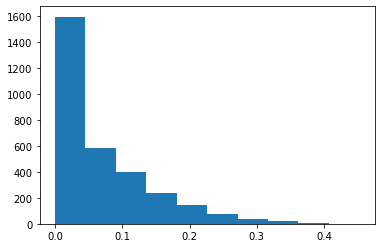

In [44]:
plt.hist(xCoh[y == False,0])

In [31]:
pc=0
coopIds, compIds = [0,5],[1,2,3,4]

data = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
xMI = sklearn.feature_selection.mutual_info_classif(data[0].reshape(-1, 1).astype('int'), data[1].astype('int'), discrete_features=False)
y = np.array([True])
for map in range(25):
    for repeat in range(31):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-{repeat}.npy')[..., pc]#[0][:,np.newaxis]
        for count,pair in zip(range(6),combinations(np.arange(4),2)):
            if map!=0 or repeat!=0 or count!=0:
                t = sklearn.feature_selection.mutual_info_classif(data[pair[0]].reshape(-1, 1).astype('int'), data[pair[1]].astype('int'), discrete_features=False)
                xMI = np.concatenate((xMI, t))
                y = np.concatenate((y, [count in coopIds]))

In [34]:
trainMI = xMI[len(xMI)//4:].reshape(-1, 1)
testMI = xMI[:len(xMI)//4].reshape(-1, 1)
trainY = y[len(y)//4:]
testY = y[:len(y)//4]

print(xMI.shape)

(4650,)


In [47]:
from itertools import combinations
n_players = 4
for pair in combinations(np.arange(n_players), 2):
    print(pair)

(0, 1)
(0, 2)
(0, 3)
(1, 2)
(1, 3)
(2, 3)


In [72]:
lstms = []
for repeat_id in np.arange(n_repeats):
    lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-{repeat_id}.npy'))

lstms = np.array(lstms)[..., pc]

In [94]:
from itertools import combinations
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

n_repeats = 8
lstms = []
for repeat_id in np.arange(n_repeats):
    lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-{repeat_id}.npy'))

lstms = np.array(lstms)[..., pc]

pc = 3
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = []
for repeat_id in np.arange(n_repeats):
    for p, pair in enumerate(combinations(np.arange(n_players), 2)):
        mi = mutual_info_binned(lstms[repeat_id, pair[0]],
                                lstms[repeat_id, pair[1]])
        mis.append(mi)
    print(f"Computed mutual information for repeat {repeat_id}")
mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long


coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for repeat_id in np.arange(n_repeats):
    for p in np.arange(n_pairs):
        pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

repeat_ids = np.repeat(np.arange(n_repeats), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")

Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Finished classification for fold 0
Finished classification for fold 1
Finished classification for fold 2
Finished classification for fold 3
Finished classification for fold 4
Finished classification for fold 5
Finished classification for fold 6
Finished classification for fold 7


In [85]:
np.mean(result)

0.5208333333333333

In [96]:
for fold, (train, test) in enumerate(cv.split()):
    print(train, test)

[ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] [0 1 2 3 4 5]
[ 0  1  2  3  4  5 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] [ 6  7  8  9 10 11]
[ 0  1  2  3  4  5  6  7  8  9 10 11 18 19 20 21 22 23 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] [12 13 14 15 16 17]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 24 25 26 27 28 29
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] [18 19 20 21 22 23]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] [24 25 26 27 28 29]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 36 37 38 39 40 41 42 43 44 45 46 47] [30 31 32 33 34 35]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 42

In [33]:
MIModel = sklearn.linear_model.LogisticRegression().fit(trainMI, trainY)
#r_sq = model.score(testCoh, testY)
#print(f'r sq: {r_sq}')

predY = MIModel.predict(testMI)
cm = confusion_matrix(testY, predY)
print ("Confusion Matrix: \n", cm)
print ("Accuracy:", accuracy_score(testY, predY))

Confusion Matrix: 
 [[775   0]
 [387   0]]
Accuracy: 0.6669535283993115


(array([ 53., 239., 446., 441., 247., 102.,  21.,   0.,   1.,   0.]),
 array([0.   , 0.012, 0.024, 0.036, 0.048, 0.06 , 0.072, 0.084, 0.096,
        0.108, 0.12 ]),
 <BarContainer object of 10 artists>)

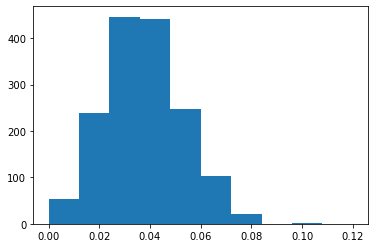

In [35]:
plt.hist(xMI[y], range=(0,0.12))

(array([ 33., 214., 586., 887., 679., 408., 193.,  72.,  21.,   7.]),
 array([0.        , 0.01276056, 0.02552111, 0.03828167, 0.05104222,
        0.06380278, 0.07656334, 0.08932389, 0.10208445, 0.114845  ,
        0.12760556]),
 <BarContainer object of 10 artists>)

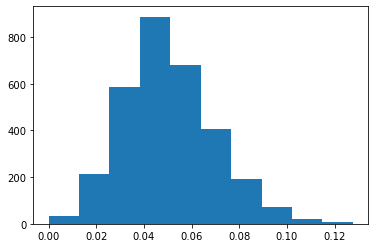

In [36]:
plt.hist(xMI[y == False])

In [38]:
tau = scipy.stats.kendalltau(data[0], data[1])
print(tau.correlation, tau.pvalue)

0.03945039373966279 7.232119924035139e-05


New Section

In [100]:
pc = 2
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
#n_pcs = 10
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = []
for map_id in np.arange(n_maps):
    lstms = []
    for repeat_id in np.arange(n_repeats):
        lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    lstms = np.array(lstms)[..., pc]
    for repeat_id in np.arange(n_repeats):
        for p, pair in enumerate(combinations(np.arange(n_players), 2)):
            mi = mutual_info_binned(lstms[repeat_id, pair[0]],
                                    lstms[repeat_id, pair[1]])
            mis.append(mi)
        print(f"Computed mutual information for repeat {repeat_id}")
mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long


coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

repeat_ids = np.repeat(np.arange(n_repeats*n_maps), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual 

0.7916666666666667

In [99]:
pc = 6
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
#n_pcs = 10
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = []
for map_id in np.arange(n_maps):
    lstms = []
    for repeat_id in np.arange(n_repeats):
        lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    lstms = np.array(lstms)[..., pc]
    for repeat_id in np.arange(n_repeats):
        for p, pair in enumerate(combinations(np.arange(n_players), 2)):
            mi = mutual_info_binned(lstms[repeat_id, pair[0]],
                                    lstms[repeat_id, pair[1]])
            mis.append(mi)
        print(f"Computed mutual information for repeat {repeat_id}")
mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long


coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

repeat_ids = np.repeat(np.arange(n_repeats*n_maps), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual 

0.7375

In [101]:
pc = 4
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
#n_pcs = 10
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = []
for map_id in np.arange(n_maps):
    lstms = []
    for repeat_id in np.arange(n_repeats):
        lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    lstms = np.array(lstms)[..., pc]
    for repeat_id in np.arange(n_repeats):
        for p, pair in enumerate(combinations(np.arange(n_players), 2)):
            mi = mutual_info_binned(lstms[repeat_id, pair[0]],
                                    lstms[repeat_id, pair[1]])
            mis.append(mi)
        print(f"Computed mutual information for repeat {repeat_id}")
mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long


coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

repeat_ids = np.repeat(np.arange(n_repeats*n_maps), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual 

0.9416666666666668

In [157]:
pc = 3
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
#n_pcs = 10
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = []
for map_id in np.arange(n_maps):
    lstms = []
    for repeat_id in np.arange(n_repeats):
        lstms.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    lstms = np.array(lstms)[..., pc]
    for repeat_id in np.arange(n_repeats):
        for p, pair in enumerate(combinations(np.arange(n_players), 2)):
            mi = mutual_info_binned(lstms[repeat_id, pair[0]],
                                    lstms[repeat_id, pair[1]])
            mis.append(mi)
        print(f"Computed mutual information for repeat {repeat_id}")
mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long


coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

#repeat_ids = np.repeat(np.arange(n_repeats*n_maps), n_pairs)
map_ids = np.repeat(np.repeat(np.arange(n_maps), n_repeats), n_pairs)
cv = PredefinedSplit(map_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual information for repeat 0
Computed mutual information for repeat 1
Computed mutual information for repeat 2
Computed mutual information for repeat 3
Computed mutual information for repeat 4
Computed mutual information for repeat 5
Computed mutual information for repeat 6
Computed mutual information for repeat 7
Computed mutual 

0.525

In [158]:
map_ids

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [143]:
#pc = 3
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
n_pcs = 6
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = np.empty(shape=(0,n_pcs))
for map_id in np.arange(n_maps):
    lstmsAll = []
    misMap = np.empty(shape=(int(n_repeats*n_pairs),0))
    for repeat_id in np.arange(n_repeats):
        lstmsAll.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    for pc in np.arange(n_pcs):
        lstms = np.array(lstmsAll)[..., pc]
        misRepeat = np.empty(shape=(0))[:, np.newaxis]
        for repeat_id in np.arange(n_repeats):
            for p, pair in enumerate(combinations(np.arange(n_players), 2)):
                mi = np.array([mutual_info_binned(lstms[repeat_id, pair[0]],
                                        lstms[repeat_id, pair[1]])])[:, np.newaxis]
                #print(mi.shape, misRepeat.shape)
                misRepeat = np.concatenate((misRepeat, mi), axis=0)
        print(misMap.shape, misRepeat.shape)
        misMap = np.concatenate((misMap, misRepeat), axis=1)
    mis = np.concatenate((mis, misMap), axis=0)
    print(mis.shape)
print(f"Computed mutual information for map {map_id}")
#mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long
print(mis.shape)

coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)

repeat_ids = np.repeat(np.arange(n_repeats), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

(48, 0) (48, 1)
(48, 1) (48, 1)
(48, 2) (48, 1)
(48, 3) (48, 1)
(48, 4) (48, 1)
(48, 5) (48, 1)
(48, 6)
(48, 0) (48, 1)
(48, 1) (48, 1)
(48, 2) (48, 1)
(48, 3) (48, 1)
(48, 4) (48, 1)
(48, 5) (48, 1)
(96, 6)
(48, 0) (48, 1)
(48, 1) (48, 1)
(48, 2) (48, 1)
(48, 3) (48, 1)
(48, 4) (48, 1)
(48, 5) (48, 1)
(144, 6)
(48, 0) (48, 1)
(48, 1) (48, 1)
(48, 2) (48, 1)
(48, 3) (48, 1)
(48, 4) (48, 1)
(48, 5) (48, 1)
(192, 6)
(48, 0) (48, 1)
(48, 1) (48, 1)
(48, 2) (48, 1)
(48, 3) (48, 1)
(48, 4) (48, 1)
(48, 5) (48, 1)
(240, 6)
Computed mutual information for map 4
(240, 6)
Finished classification for fold 0
Finished classification for fold 1
Finished classification for fold 2
Finished classification for fold 3
Finished classification for fold 4
Finished classification for fold 5
Finished classification for fold 6
Finished classification for fold 7


0.9791666666666667

In [144]:
print(mis.shape)
print(pair_ids.shape)

(240, 6)
(240,)


In [18]:
#pc = 3
n_repeats = 8
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
matchup_id = 0
map_id = 0
n_pcs = 6
n_maps = 5
# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
mis = np.empty(shape=(0,n_pcs))
for map_id in np.arange(n_maps):
    lstmsAll = []
    misMap = np.empty(shape=(int(n_repeats*n_pairs),0))
    for repeat_id in np.arange(n_repeats):
        lstmsAll.append(np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy'))
    for pc in np.arange(n_pcs):
        lstms = np.array(lstmsAll)[..., pc]
        misRepeat = np.empty(shape=(0))[:, np.newaxis]
        for repeat_id in np.arange(n_repeats):
            for p, pair in enumerate(combinations(np.arange(n_players), 2)):
                print(lstms.shape)
                mi = np.array([window_isc(lstms[repeat_id].T)])[:, np.newaxis]
                print(np.mean(mi[0,0,...,0])[np.newaxis, np.newaxis],np.mean(mi[0,0,...,0])[np.newaxis, np.newaxis].shape, misRepeat.shape)
                misRepeat = np.concatenate((misRepeat, np.mean(mi[0,0,...,0])[np.newaxis, np.newaxis]), axis=0)
        print(misMap.shape, misRepeat.shape)
        misMap = np.concatenate((misMap, misRepeat), axis=1)
    mis = np.concatenate((mis, misMap), axis=0)
    print(mis.shape)
print(f"Computed mutual information for map {map_id}")
#mis = np.array(mis)[:, np.newaxis]
# output MIs should be n_repeats * n_pairs long
print(mis.shape)

'''coop_ids, comp_ids = (0, 5), (1, 2, 3, 4)
pair_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        for p in np.arange(n_pairs):
            pair_ids.append(0 if p in coop_ids else 1)
pair_ids = np.array(pair_ids)'''

repeat_ids = np.repeat(np.arange(n_repeats), n_pairs)
cv = PredefinedSplit(repeat_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    
    clf = LinearRegression(class_weight='balanced')
    clf.fit(mis[train], pair_ids[train])
    
    pred = clf.predict(mis[test])
    result.append(accuracy_score(pred, pair_ids[test]))
    print(f"Finished classification for fold {fold}")
    
np.mean(result)

(8, 4, 4501)
Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows
[[-0.03602257]] (1, 1) (0, 1)
(8, 4, 4501)
Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC for 3500 windows
Finished computing ISC for 4000 windows
[[-0.03602257]] (1, 1) (1, 1)
(8, 4, 4501)
Finished computing ISC for 500 windows
Finished computing ISC for 1000 windows
Finished computing ISC for 1500 windows
Finished computing ISC for 2000 windows
Finished computing ISC for 2500 windows
Finished computing ISC for 3000 windows
Finished computing ISC f

KeyboardInterrupt: 

In [ ]:
from scipy.stats import zscore

#pc = 3
n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
pairs = combinations(np.arange(n_players), 2)

pc_id = 5

pair = (0,1)

# lstms shape = (2 repeats, 4 players, 4501 samples, 1 PC)
lstms = np.full((n_maps, n_repeats, n_samples, 2), np.nan)
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
        lstms[map_id, repeat_id] = zscore(data[pair, :, pc_id].T, axis=0)
        map_ids.extend([map_id]*n_samples)
    print(f'Finished loading {map_id}')

Finished loading 0
Finished loading 1
Finished loading 2
Finished loading 3
Finished loading 4
Finished loading 5
Finished loading 6
Finished loading 7
Finished loading 8
Finished loading 9
Finished loading 10
Finished loading 11
Finished loading 12
Finished loading 13
Finished loading 14
Finished loading 15
Finished loading 16
Finished loading 17
Finished loading 18
Finished loading 19
Finished loading 20
Finished loading 21
Finished loading 22
Finished loading 23
Finished loading 24
Finished loading 25
Finished loading 26
Finished loading 27
Finished loading 28
Finished loading 29


In [77]:
for i in combinations(np.arange(4),2):
    print(i)

(0, 1)
(0, 2)
(0, 3)
(1, 2)
(1, 3)
(2, 3)


In [75]:
data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
data[(0,3), :, pc_id].shape

(2, 4501)

In [26]:
lstms.shape

(32, 32, 4501, 2)

In [41]:
np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze().shape

(32, 144032, 2)

In [42]:
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
lstms_stack.shape

(4609024, 2)

In [87]:
lstms_stack[train, 0].shape

(0,)

In [60]:
lstms_stack.shape

(4609024, 2)

In [86]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

cv = PredefinedSplit(map_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    reg = LinearRegression()
    reg.fit(lstms_stack[train, 0][:, np.newaxis], lstms_stack[train, 1])
    pred = reg.predict(lstms_stack[test, 0][:, np.newaxis])
    #pr = pearsonr(pred, lstms_stack[test, 1])
    result.append(pearsonr(pred, lstms_stack[test, 1])[0])
    print(f"Finished ISC regression for fold {fold}")

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.

In [67]:
lstms_stack[train, 1][:10]

array([2.65481655, 3.20743945, 3.25264248, 3.05884118, 3.04685107,
       2.77241306, 2.79603282, 2.75793082, 2.62809116, 2.4643053 ])

In [51]:
pred.shape

(144032,)

In [55]:
np.mean(result)

0.07960794394014986

In [46]:
from scipy.stats import zscore

n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142

# data shape = (2 repeats, 4 players, 4501 samples, 142 PCs)
lstms = np.full((n_maps, n_repeats, n_samples, n_players, n_pcs), np.nan)
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
        lstms[map_id, repeat_id] = zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
        map_ids.extend([map_id]*n_samples)
    print(f'Finished loading {map_id}')
    
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
print(f"LSTMs stack shape: {lstms_stack.shape}")

KeyboardInterrupt: 

In [116]:
d = data[:, :, :n_pcs]

In [120]:
np.moveaxis(d, 0, 1).shape

(4501, 4, 142)

In [91]:
lstms_comp_stack = np.dstack(np.split(lstms_comp, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_comp_stack = np.hstack(np.split(lstms_comp_stack, n_maps, axis=0)).squeeze()
lstms_comp_stack.shape

(4609024, 2)

In [100]:
pred.shape

(144032,)

In [99]:
pred.shape[0] // 32

4501

In [102]:
n_repeats

32

In [101]:
lstms_comp_stack[test, 1].shape


(144032,)

In [103]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

cv = PredefinedSplit(map_ids)

results = np.full((n_pcs, n_pairs, n_maps*n_repeats), np.nan)
for pc_id in np.arange(n_pcs):
    for pair_id, pair in enumerate(pairs):
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
            print(f"Finished ISC regression for fold {fold}")
        results[pc_id, pair_id] = np.array(result)

Finished ISC regression for fold 0
Finished ISC regression for fold 1
Finished ISC regression for fold 2
Finished ISC regression for fold 3
Finished ISC regression for fold 4
Finished ISC regression for fold 5
Finished ISC regression for fold 6
Finished ISC regression for fold 7
Finished ISC regression for fold 8
Finished ISC regression for fold 9
Finished ISC regression for fold 10
Finished ISC regression for fold 11
Finished ISC regression for fold 12
Finished ISC regression for fold 13
Finished ISC regression for fold 14
Finished ISC regression for fold 15
Finished ISC regression for fold 16
Finished ISC regression for fold 17
Finished ISC regression for fold 18
Finished ISC regression for fold 19
Finished ISC regression for fold 20
Finished ISC regression for fold 21
Finished ISC regression for fold 22
Finished ISC regression for fold 23
Finished ISC regression for fold 24
Finished ISC regression for fold 25
Finished ISC regression for fold 26
Finished ISC regression for fold 27
Fi

In [104]:
len(result)

1024

In [6]:
result

NameError: name 'result' is not defined

In [107]:
np.mean(result)

0.04422315220743482

In [109]:
from scipy.stats import ttest_1samp
ttest_1samp(result, popmean=0)

Ttest_1sampResult(statistic=23.86310881200978, pvalue=2.0627918714689083e-100)

In [105]:
result

[0.08680005488221268,
 0.042408680342309525,
 0.0854618907510391,
 0.062455321010523215,
 0.010408716699370945,
 -0.0011988077047708605,
 -0.02798839188938964,
 0.06948564833665524,
 -0.09193408875085934,
 0.010808713382995754,
 -0.0004835677293776111,
 0.01603670542494299,
 0.02083319144678277,
 -0.012893681696482771,
 -0.014459228634669374,
 0.06525081796150514,
 -0.04242028305581188,
 0.007048963947817281,
 0.032561349311163695,
 -0.0006329391144017336,
 0.0032471614657996195,
 0.03398592434775295,
 0.06877306092357939,
 0.026346230338503356,
 0.0015719772671228729,
 0.0035661825276530577,
 0.11282131517950345,
 0.006290656092531582,
 -0.005240862761629581,
 -0.011248129135660506,
 -0.01658603395200268,
 -0.018038698865170816,
 0.06471138825738999,
 -0.037698711451924403,
 -0.02989539303902944,
 0.07124801154661844,
 -0.0019209952953602033,
 0.013037662613398015,
 0.013857133889970216,
 0.016142672736841945,
 0.07628515964936114,
 0.1158317258087638,
 0.05361013937246778,
 0.1339846

In [1]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

cv = PredefinedSplit(map_ids)

result = []
for fold, (train, test) in enumerate(cv.split()):
    reg = LinearRegression()
    reg.fit(lstms_comp_stack[train, 0][:, np.newaxis], lstms_comp_stack[train, 1])
    pred = reg.predict(lstms_comp_stack[test, 0][:, np.newaxis])
    #pr = pearsonr(pred, lstms_stack[test, 1])
    result.append(pearsonr(pred, lstms_comp_stack[test, 1])[0])
    print(f"Finished ISC regression for fold {fold}")

NameError: name 'PredefinedSplit' is not defined

START HERE

In [ ]:
from scipy.stats import zscore

n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142

# data shape = (2 repeats, 4 players, 4501 samples, 142 PCs)
lstms = np.full((n_maps, n_repeats, n_samples, n_players, n_pcs), np.nan)
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
        lstms[map_id, repeat_id] = zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
        map_ids.extend([map_id]*n_samples)
    print(f'Finished loading {map_id}')
    
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
print(f"LSTMs stack shape: {lstms_stack.shape}")

Finished loading 0
Finished loading 1
Finished loading 2
Finished loading 3
Finished loading 4
Finished loading 5
Finished loading 6
Finished loading 7
Finished loading 8
Finished loading 9
Finished loading 10
Finished loading 11
Finished loading 12
Finished loading 13
Finished loading 14
Finished loading 15
Finished loading 16
Finished loading 17
Finished loading 18
Finished loading 19
Finished loading 20
Finished loading 21
Finished loading 22
Finished loading 23
Finished loading 24
Finished loading 25
Finished loading 26
Finished loading 27


In [10]:
lstms_stack = np.dstack(np.split(lstms[...,:20], n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
lstms_stack.shape

MemoryError: Unable to allocate 2.75 GiB for an array with shape (32, 1, 144032, 4, 20) and data type float64

In [18]:
lstms_stack[..., 140]

array([[ 10.04928304,   8.11141471,   7.24871667,   7.24320961],
       [ -5.76356905,  -8.89271434,  -8.94120571,  -9.57951776],
       [ -7.09620115, -10.13270499,  -8.07620725,  -9.14799479],
       ...,
       [  0.66062732,   0.99121882,  -0.81794669,   0.52498859],
       [  0.72084933,   1.33834064,  -0.63459271,   0.52729143],
       [  1.0904056 ,   1.56506563,  -0.5174484 ,   0.40316478]])

In [ ]:
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

cv = PredefinedSplit(map_ids)

results = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(50):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 0
Finished ISC regression for PC 2, pair 1
Finished ISC regression for PC 2, pair 2
Finished ISC regression for PC 2, pair 3
Finished ISC regression for PC 2, pair 4
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 0
Finished ISC regression for PC 3, pair 1
Finished ISC regression for PC 3, pair 2
Finished ISC regression for PC 3, pair 3
Finished ISC regression for PC 3, pair 4
Finished ISC regression for PC 3, pair 5
Finished ISC reg

In [15]:
results = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)

In [19]:
n_pcs

142

In [15]:
results.shape

(142, 6, 1024)

In [24]:
for pair_id, pair in enumerate(pairs):
    print(pair_id)

In [29]:
from scipy.stats import ttest_1samp
ttest_1samp(results[0, 0], popmean=0)

Ttest_1sampResult(statistic=45.44833514481938, pvalue=6.067786915394582e-11)

In [30]:
results.shape

(142, 6, 9)

In [36]:
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        print(f'PC {pc_id}, pair {pair_id}:',ttest_1samp(results[pc_id, pair_id], popmean=0))
    raise

PC 0, pair 0: Ttest_1sampResult(statistic=45.44833514481938, pvalue=6.067786915394582e-11)
PC 0, pair 1: Ttest_1sampResult(statistic=56.567463653062894, pvalue=1.058718173996329e-11)
PC 0, pair 2: Ttest_1sampResult(statistic=66.93451578390157, pvalue=2.762025684369968e-12)
PC 0, pair 3: Ttest_1sampResult(statistic=33.9908824254531, pvalue=6.130975711747416e-10)
PC 0, pair 4: Ttest_1sampResult(statistic=45.09156784708071, pvalue=6.461236396736217e-11)
PC 0, pair 5: Ttest_1sampResult(statistic=37.3926907345508, pvalue=2.870806211924376e-10)


RuntimeError: No active exception to reraise

In [17]:
results[..., 49]

array([[        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan],
       [        nan,         nan,         nan,    

In [ ]:
for pc_id in np.arange(n_pcs):
    print(f'PC {pc_id}, cooperative pairs:',ttest_1samp(np.mean(results[pc_id, (0,5)], axis=0), popmean=0))
    print(f'PC {pc_id}, competitive pairs:',ttest_1samp(np.mean(results[pc_id, 1:4], axis=0), popmean=0))

In [45]:
np.mean(results[pc_id, (0,5)], axis=0)

array([0.64767789, 0.73365145, 0.68443361, 0.76718687, 0.7573313 ,
       0.7783105 , 0.67337206, 0.69059499, 0.70668819])

In [ ]:
print(f'PC {pc_id}, cooperative pairs:',ttest_1samp(results[pc_id, (0,5)], popmean=0))
print(f'PC {pc_id}, competitive pairs:',ttest_1samp(results[pc_id, 1:4], popmean=0))